# Retain/Forget Loss Convergence

This notebook loads all `training_log.json` files under the current OMD-TCH output folder and plots:
- Per-run retain and forget losses by epoch
- Mean and standard deviation across runs

Use it to quickly check whether training appears to converge.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Folder that contains seed_* subfolders.
base_dir = Path('.').resolve()

log_files = sorted(base_dir.glob('seed_*_train_*/training_log.json'))
print(f'Base directory: {base_dir}')
print(f'Found {len(log_files)} logs')
for p in log_files:
    print(' -', p.relative_to(base_dir))

Base directory: /home/yuen_chen/EUPMU-Efficient-Utility-Preserving-Machine-Unlearning/classification/classification_EU_RL
Found 0 logs


In [3]:
records = []
for log_path in log_files:
    with open(log_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    run_name = log_path.parent.name
    for ep in data.get('epochs', []):
        records.append({
            'run': run_name,
            'epoch': ep.get('epoch'),
            'retain_loss': ep.get('retain_loss'),
            'forget_loss': ep.get('forget_loss'),
            'retain_acc': ep.get('retain_acc'),
            'forget_acc': ep.get('forget_acc'),
            'test_acc': ep.get('test_acc'),
        })

df = pd.DataFrame(records).sort_values(['run', 'epoch']).reset_index(drop=True)
if df.empty:
    raise ValueError('No epoch records found. Check the log format/path.')

display(df.head())
print(f'Total rows: {len(df)}, runs: {df["run"].nunique()}, max epoch: {df["epoch"].max()}')

KeyError: 'run'

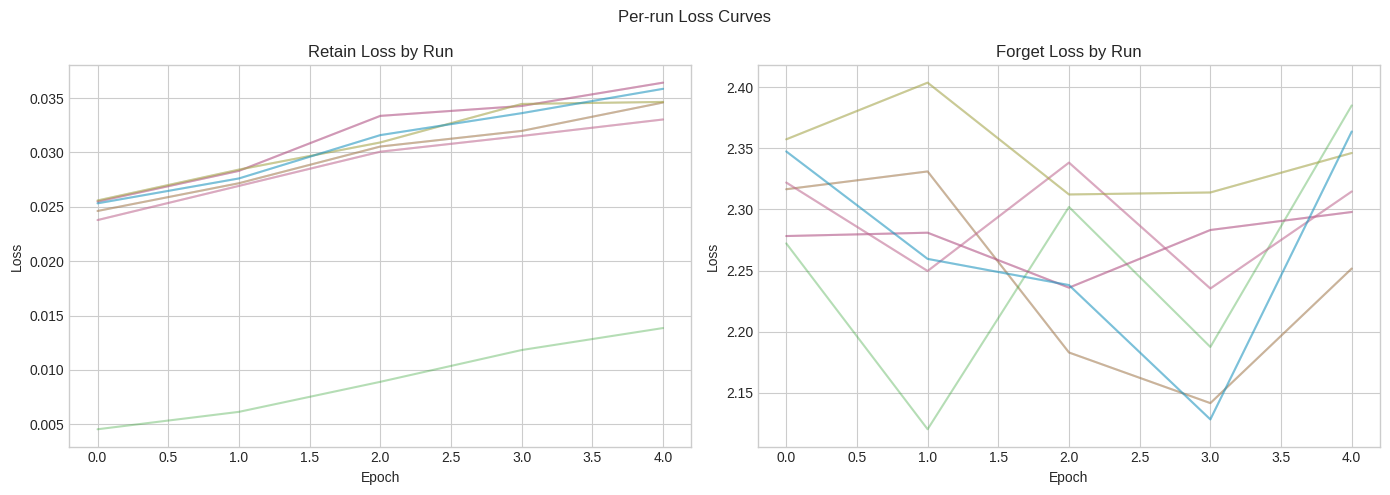

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for run, g in df.groupby('run'):
    axes[0].plot(g['epoch'], g['retain_loss'], alpha=0.35, linewidth=1.5)
    axes[1].plot(g['epoch'], g['forget_loss'], alpha=0.35, linewidth=1.5)

axes[0].set_title('Retain Loss by Run')
axes[1].set_title('Forget Loss by Run')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')

plt.suptitle('Per-run Loss Curves')
plt.tight_layout()
plt.show()

In [ ]:
summary = (
    df.groupby('epoch')[['retain_loss', 'forget_loss']]
      .agg(['mean', 'std'])
      .reset_index()
)
summary.columns = ['epoch', 'retain_mean', 'retain_std', 'forget_mean', 'forget_std']
display(summary.head())

NameError: name 'df' is not defined

In [ ]:
x = summary['epoch'].to_numpy()

retain_mean = summary['retain_mean'].to_numpy()
retain_std = summary['retain_std'].fillna(0).to_numpy()
forget_mean = summary['forget_mean'].to_numpy()
forget_std = summary['forget_std'].fillna(0).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(x, retain_mean, color='tab:blue', linewidth=2, label='mean')
axes[0].fill_between(x, retain_mean - retain_std, retain_mean + retain_std, color='tab:blue', alpha=0.2, label='mean +/- std')
axes[0].set_title('Retain Loss (Mean +/- Std)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(x, forget_mean, color='tab:red', linewidth=2, label='mean')
axes[1].fill_between(x, forget_mean - forget_std, forget_mean + forget_std, color='tab:red', alpha=0.2, label='mean +/- std')
axes[1].set_title('Forget Loss (Mean +/- Std)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Aggregate Convergence View Across Runs')
plt.tight_layout()
plt.show()

NameError: name 'summary' is not defined

In [ ]:

# Optional: convergence deltas between the final two epochs (mean curves).
if len(summary) >= 2:
    retain_delta = summary['retain_mean'].iloc[-1] - summary['retain_mean'].iloc[-2]
    forget_delta = summary['forget_mean'].iloc[-1] - summary['forget_mean'].iloc[-2]
    print(f'Retain mean delta (last epoch): {retain_delta:+.6f}')
    print(f'Forget mean delta (last epoch): {forget_delta:+.6f}')
else:
    print('Not enough epochs to compute a final-step delta.')

NameError: name 'summary' is not defined

In [4]:
# Convergence check per run using last-k epoch behavior.
# You can tighten/relax thresholds depending on how strict you want to be.
last_k = 3
retain_slope_tol = 0.004   # abs(slope) <= tol means near-flat retain loss
forget_slope_tol = 0.12    # abs(slope) <= tol means near-flat forget loss
retain_range_tol = 0.012   # (max-min) in last_k retain losses
forget_range_tol = 0.30    # (max-min) in last_k forget losses

if df['epoch'].nunique() < last_k:
    raise ValueError(f'Need at least {last_k} epochs for this convergence check.')

def line_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan
    # Least-squares slope for trend over epochs.
    return np.polyfit(x, y, 1)[0]

rows = []
for run, g in df.groupby('run'):
    g = g.sort_values('epoch')
    tail = g.tail(last_k)

    rs = line_slope(tail['epoch'], tail['retain_loss'])
    fs = line_slope(tail['epoch'], tail['forget_loss'])
    rr = tail['retain_loss'].max() - tail['retain_loss'].min()
    fr = tail['forget_loss'].max() - tail['forget_loss'].min()

    converged = (
        abs(rs) <= retain_slope_tol
        and abs(fs) <= forget_slope_tol
        and rr <= retain_range_tol
        and fr <= forget_range_tol
    )

    rows.append({
        'run': run,
        'retain_slope_last_k': rs,
        'forget_slope_last_k': fs,
        'retain_range_last_k': rr,
        'forget_range_last_k': fr,
        'converged': converged,
    })

conv_df = pd.DataFrame(rows).sort_values('run').reset_index(drop=True)
display(conv_df)

n_total = len(conv_df)
n_conv = int(conv_df['converged'].sum())
print(f'Converged runs: {n_conv}/{n_total} ({100.0*n_conv/n_total:.1f}%)')
print('Thresholds:')
print(f'  retain |slope| <= {retain_slope_tol}, range <= {retain_range_tol}')
print(f'  forget |slope| <= {forget_slope_tol}, range <= {forget_range_tol}')

status_counts = conv_df['converged'].value_counts().reindex([True, False], fill_value=0)
plt.figure(figsize=(5, 3.5))
plt.bar(['Converged', 'Not converged'], [status_counts[True], status_counts[False]], color=['tab:green', 'tab:orange'])
plt.ylabel('Number of runs')
plt.title(f'Convergence Status (last {last_k} epochs)')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [5]:
# Detailed view: one panel per run, plotting both retain and forget losses.
runs = sorted(df['run'].unique())
n_runs = len(runs)

ncols = 3
nrows = int(np.ceil(n_runs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.8 * nrows), sharex=True)

# Normalize axes handling for cases like a single row/column.
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = np.array([axes])

for i, run_name in enumerate(runs):
    ax = axes[i]
    g = df[df['run'] == run_name].sort_values('epoch')

    ax.plot(g['epoch'], g['retain_loss'], marker='o', linewidth=1.8, color='tab:blue', label='retain_loss')
    ax.plot(g['epoch'], g['forget_loss'], marker='s', linewidth=1.8, color='tab:red', label='forget_loss')

    ax.set_title(run_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.25)

# Hide any unused subplot slots.
for j in range(n_runs, len(axes)):
    axes[j].axis('off')

# Single legend for the full figure.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Retain vs Forget Loss by Run', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

NameError: name 'df' is not defined

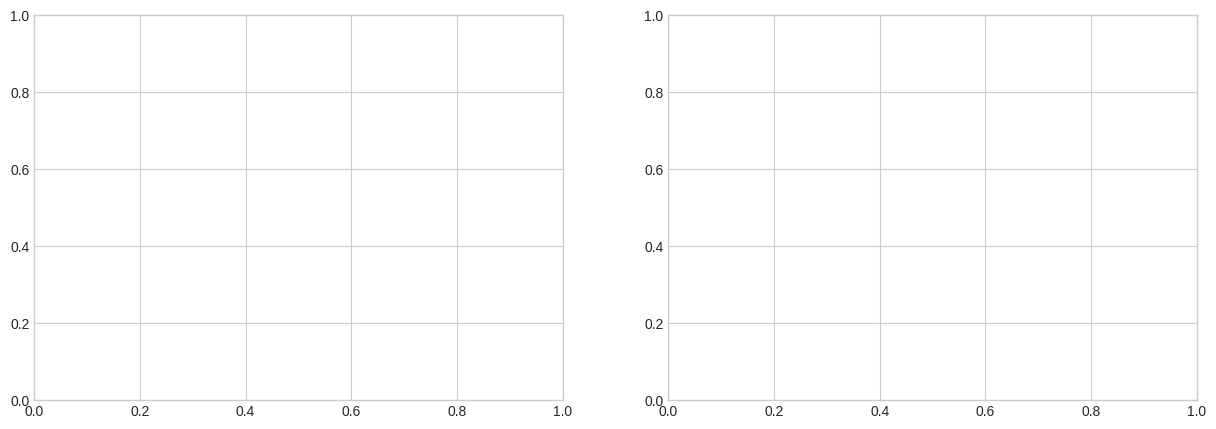

In [6]:
# Overlay all runs: retain losses on one axis, forget losses on the other.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for run_name, g in df.groupby('run'):
    g = g.sort_values('epoch')
    axes[0].plot(g['epoch'], g['retain_loss'], marker='o', linewidth=1.6, alpha=0.9, label=run_name)
    axes[1].plot(g['epoch'], g['forget_loss'], marker='s', linewidth=1.6, alpha=0.9, label=run_name)

axes[0].set_title('All Runs: Retain Loss')
axes[1].set_title('All Runs: Forget Loss')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.25)

# Keep legend readable when there are many runs.
axes[1].legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.suptitle('Loss Curves Across Runs')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

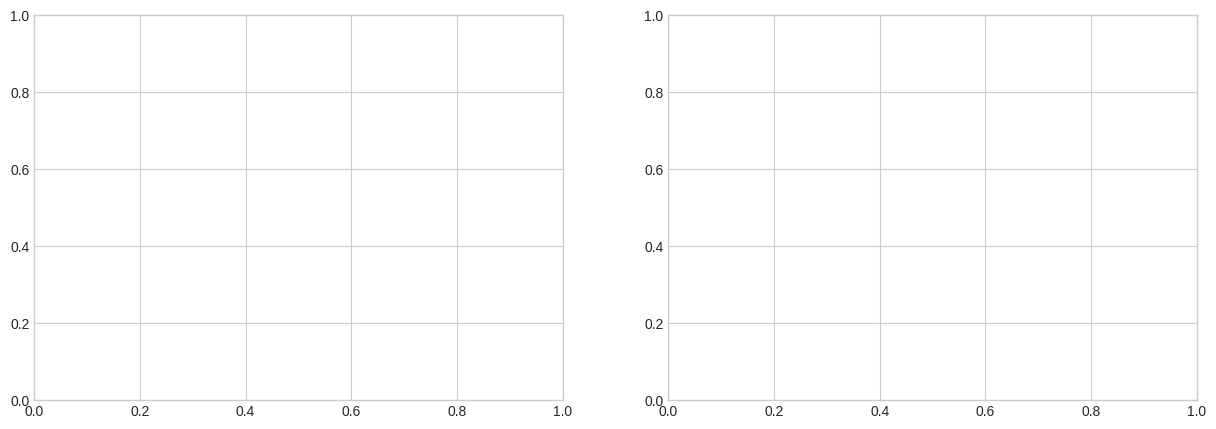

In [ ]:
# Overlay all runs: validation retain accuracy on one axis, validation unlearning accuracy on the other.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for run_name, g in df.groupby('run'):
    g = g.sort_values('epoch')
    axes[0].plot(g['epoch'], g['retain_acc'], marker='o', linewidth=1.6, alpha=0.9, label=run_name)
    axes[1].plot(g['epoch'], g['forget_acc'], marker='s', linewidth=1.6, alpha=0.9, label=run_name)

axes[0].set_title('All Runs: Validation Retain Accuracy')
axes[1].set_title('All Runs: Validation Unlearning Accuracy')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(alpha=0.25)

axes[1].legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.suptitle('Validation Accuracies Across Runs')
plt.tight_layout()
plt.show()

In [7]:
# Comparison baseline: load EUPMU (eu) runs and plot the same metrics.
eu_dir = (base_dir.parent / 'eu').resolve()
eu_log_files = sorted(eu_dir.glob('seed_*_train_*/training_log.json'))
print(f'EUPMU directory: {eu_dir}')
print(f'Found {len(eu_log_files)} EUPMU logs')

if len(eu_log_files) == 0:
    raise ValueError('No EUPMU logs found. Check eu_dir path.')

eu_records = []
for log_path in eu_log_files:
    with open(log_path, 'r', encoding='utf-8') as f:
        data_eu = json.load(f)

    run_name = log_path.parent.name
    for ep in data_eu.get('epochs', []):
        eu_records.append({
            'run': run_name,
            'epoch': ep.get('epoch'),
            'retain_loss': ep.get('retain_loss'),
            'forget_loss': ep.get('forget_loss'),
            'retain_acc': ep.get('retain_acc'),
            'forget_acc': ep.get('forget_acc'),
            'test_acc': ep.get('test_acc'),
        })

df_eu = pd.DataFrame(eu_records).sort_values(['run', 'epoch']).reset_index(drop=True)
display(df_eu.head())

# EUPMU loss curves across runs.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for run_name, g in df_eu.groupby('run'):
    g = g.sort_values('epoch')
    axes[0].plot(g['epoch'], g['retain_loss'], marker='o', linewidth=1.6, alpha=0.9, label=run_name)
    axes[1].plot(g['epoch'], g['forget_loss'], marker='s', linewidth=1.6, alpha=0.9, label=run_name)

axes[0].set_title('EUPMU: All Runs Retain Loss')
axes[1].set_title('EUPMU: All Runs Forget Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.25)
axes[1].legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.suptitle('EUPMU Loss Curves Across Runs')
plt.tight_layout()
plt.show()

# EUPMU validation accuracy curves across runs.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for run_name, g in df_eu.groupby('run'):
    g = g.sort_values('epoch')
    axes[0].plot(g['epoch'], g['retain_acc'], marker='o', linewidth=1.6, alpha=0.9, label=run_name)
    axes[1].plot(g['epoch'], g['forget_acc'], marker='s', linewidth=1.6, alpha=0.9, label=run_name)

axes[0].set_title('EUPMU: Validation Retain Accuracy')
axes[1].set_title('EUPMU: Validation Unlearning Accuracy')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(alpha=0.25)
axes[1].legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.suptitle('EUPMU Validation Accuracies Across Runs')
plt.tight_layout()
plt.show()

EUPMU directory: /home/yuen_chen/EUPMU-Efficient-Utility-Preserving-Machine-Unlearning/classification/eu
Found 0 EUPMU logs


ValueError: No EUPMU logs found. Check eu_dir path.

In [8]:
# Direct comparison: OMD-TCH (current folder) vs EUPMU (eu) with mean +/- std.
# Ensure EUPMU dataframe exists even if the previous cell was not run.
if 'df_eu' not in globals() or df_eu.empty:
    eu_dir = (base_dir.parent / 'eu').resolve()
    eu_log_files = sorted(eu_dir.glob('seed_*_train_*/training_log.json'))
    eu_records = []
    for log_path in eu_log_files:
        with open(log_path, 'r', encoding='utf-8') as f:
            data_eu = json.load(f)
        run_name = log_path.parent.name
        for ep in data_eu.get('epochs', []):
            eu_records.append({
                'run': run_name,
                'epoch': ep.get('epoch'),
                'retain_loss': ep.get('retain_loss'),
                'forget_loss': ep.get('forget_loss'),
                'retain_acc': ep.get('retain_acc'),
                'forget_acc': ep.get('forget_acc'),
                'test_acc': ep.get('test_acc'),
            })
    df_eu = pd.DataFrame(eu_records).sort_values(['run', 'epoch']).reset_index(drop=True)

def summarize_by_epoch(frame, cols):
    out = frame.groupby('epoch')[cols].agg(['mean', 'std']).reset_index()
    out.columns = ['epoch'] + [f'{c}_{s}' for c in cols for s in ('mean', 'std')]
    return out

metrics = ['retain_loss', 'forget_loss', 'retain_acc', 'forget_acc']
s_omd = summarize_by_epoch(df, metrics)
s_eu = summarize_by_epoch(df_eu, metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_cfg = [
    ('retain_loss', 'Retain Loss'),
    ('forget_loss', 'Forget Loss'),
    ('retain_acc', 'Validation Retain Accuracy (%)'),
    ('forget_acc', 'Validation Unlearning Accuracy (%)'),
]

for ax, (m, title) in zip(axes.flatten(), plot_cfg):
    x1 = s_omd['epoch'].to_numpy()
    y1 = s_omd[f'{m}_mean'].to_numpy()
    e1 = s_omd[f'{m}_std'].fillna(0).to_numpy()

    x2 = s_eu['epoch'].to_numpy()
    y2 = s_eu[f'{m}_mean'].to_numpy()
    e2 = s_eu[f'{m}_std'].fillna(0).to_numpy()

    ax.plot(x1, y1, color='tab:blue', linewidth=2, label='OMD-TCH mean')
    ax.fill_between(x1, y1 - e1, y1 + e1, color='tab:blue', alpha=0.2)

    ax.plot(x2, y2, color='tab:orange', linewidth=2, label='EUPMU mean')
    ax.fill_between(x2, y2 - e2, y2 + e2, color='tab:orange', alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.25)

axes[0, 0].legend(loc='best', frameon=False)
plt.suptitle('OMD-TCH vs EUPMU (Mean +/- Std Across Runs)')
plt.tight_layout()
plt.show()

# Final epoch summary table for quick numeric comparison.
last_epoch_omd = int(df['epoch'].max())
last_epoch_eu = int(df_eu['epoch'].max())
final_summary = pd.DataFrame([
    {
        'method': 'OMD-TCH',
        'last_epoch': last_epoch_omd,
        'retain_loss_mean': s_omd.loc[s_omd['epoch'] == last_epoch_omd, 'retain_loss_mean'].iloc[0],
        'forget_loss_mean': s_omd.loc[s_omd['epoch'] == last_epoch_omd, 'forget_loss_mean'].iloc[0],
        'retain_acc_mean': s_omd.loc[s_omd['epoch'] == last_epoch_omd, 'retain_acc_mean'].iloc[0],
        'ua_mean': s_omd.loc[s_omd['epoch'] == last_epoch_omd, 'forget_acc_mean'].iloc[0],
    },
    {
        'method': 'EUPMU',
        'last_epoch': last_epoch_eu,
        'retain_loss_mean': s_eu.loc[s_eu['epoch'] == last_epoch_eu, 'retain_loss_mean'].iloc[0],
        'forget_loss_mean': s_eu.loc[s_eu['epoch'] == last_epoch_eu, 'forget_loss_mean'].iloc[0],
        'retain_acc_mean': s_eu.loc[s_eu['epoch'] == last_epoch_eu, 'retain_acc_mean'].iloc[0],
        'ua_mean': s_eu.loc[s_eu['epoch'] == last_epoch_eu, 'forget_acc_mean'].iloc[0],
    },
])

display(final_summary)

KeyError: 'run'

Found methods and seed-runs:
method
omd_tch_eg     5
omd_tch_pgd    5
Name: run, dtype: int64


,method,run,epoch,retain_loss,forget_loss,retain_acc,forget_acc,test_acc
0,omd_tch_eg,seed_1_train_1,0,0.0045,2.2722,100.00,82.18,94.83
1,omd_tch_eg,seed_1_train_1,1,0.0061,2.1201,100.00,66.07,94.82
2,omd_tch_eg,seed_1_train_1,2,0.0089,2.3021,100.00,92.67,94.87
3,omd_tch_eg,seed_1_train_1,3,0.0118,2.1875,100.00,71.47,94.69
4,omd_tch_eg,seed_1_train_1,4,0.0139,2.3852,99.99,97.64,94.69


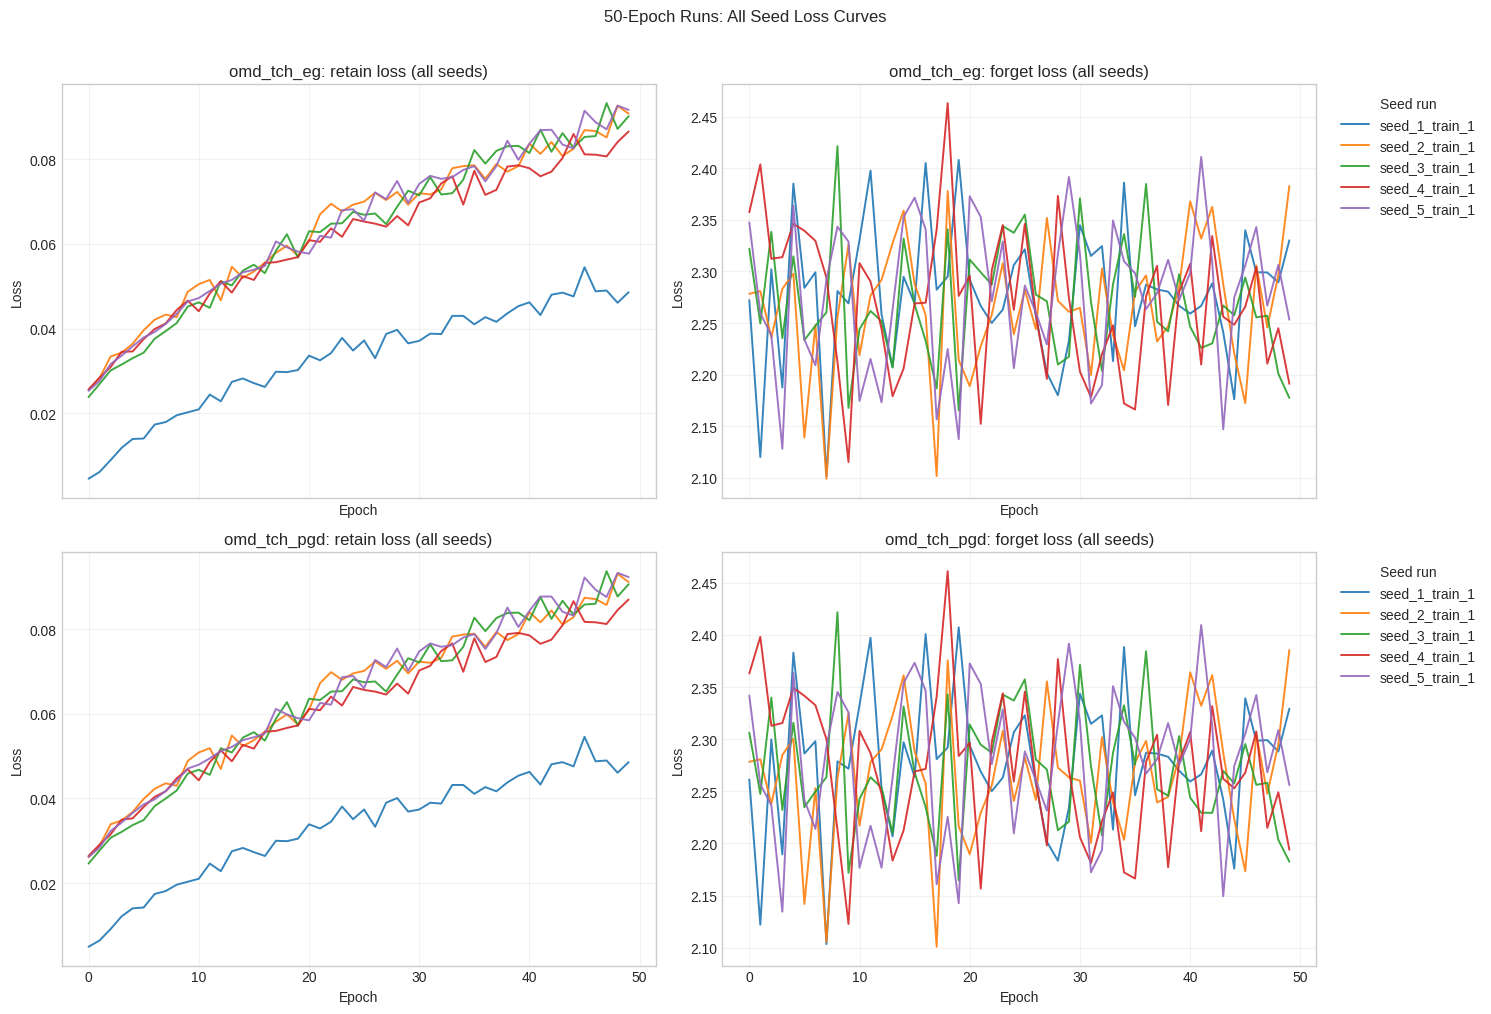

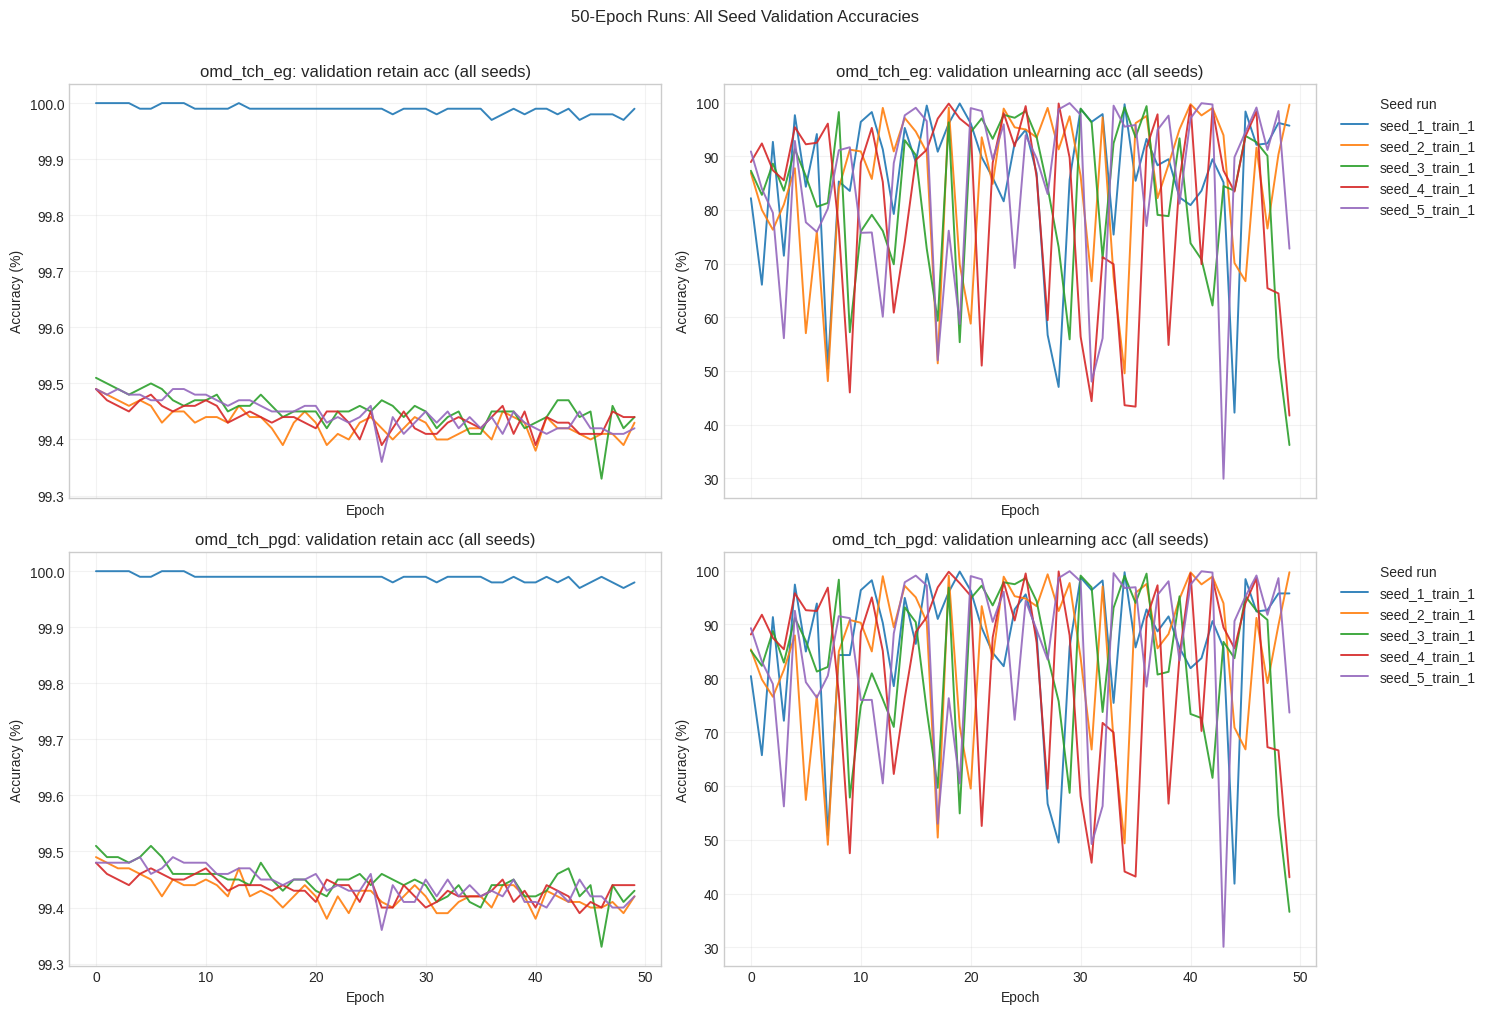

In [9]:
# Plot all seeds for runs that completed 50 epochs (epoch_50 folders in output_omd_sweep).
this_dir = Path('.').resolve()

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'output_omd_sweep').exists() and (candidate / 'output').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate project root from {start}')

project_root = find_project_root(this_dir)
sweep_root = project_root / 'output_omd_sweep' / 'resnet18' / 'cifar10' / 'forget_10.0%' / 'RL'
methods = ['omd_tch_eg', 'omd_tch_pgd']

records_50 = []
for method in methods:
    pattern = sweep_root / method
    logs = sorted(pattern.glob('seed_*_train_*/eta_*_epoch_50/training_log.json'))
    for log_path in logs:
        run_name = log_path.parent.parent.name  # seed_*_train_*
        with open(log_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        for ep in data.get('epochs', []):
            records_50.append({
                'method': method,
                'run': run_name,
                'epoch': ep.get('epoch'),
                'retain_loss': ep.get('retain_loss'),
                'forget_loss': ep.get('forget_loss'),
                'retain_acc': ep.get('retain_acc'),
                'forget_acc': ep.get('forget_acc'),
                'test_acc': ep.get('test_acc'),
            })

df50 = pd.DataFrame(records_50).sort_values(['method', 'run', 'epoch']).reset_index(drop=True)
if df50.empty:
    raise ValueError(f'No 50-epoch logs found under {sweep_root}')

print('Found methods and seed-runs:')
print(df50.groupby('method')['run'].nunique())
display(df50.head())

# Figure 1: losses (all seed curves) for each method.
fig, axes = plt.subplots(len(methods), 2, figsize=(15, 5 * len(methods)), sharex=True)
if len(methods) == 1:
    axes = np.array([axes])

for i, method in enumerate(methods):
    sub = df50[df50['method'] == method]
    for run_name, g in sub.groupby('run'):
        g = g.sort_values('epoch')
        axes[i, 0].plot(g['epoch'], g['retain_loss'], linewidth=1.4, alpha=0.9, label=run_name)
        axes[i, 1].plot(g['epoch'], g['forget_loss'], linewidth=1.4, alpha=0.9, label=run_name)

    axes[i, 0].set_title(f'{method}: retain loss (all seeds)')
    axes[i, 1].set_title(f'{method}: forget loss (all seeds)')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 0].grid(alpha=0.25)
    axes[i, 1].grid(alpha=0.25)
    axes[i, 1].legend(title='Seed run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.suptitle('50-Epoch Runs: All Seed Loss Curves', y=1.01)
plt.tight_layout()
plt.show()

# Figure 2: validation accuracies (all seed curves) for each method.
fig, axes = plt.subplots(len(methods), 2, figsize=(15, 5 * len(methods)), sharex=True)
if len(methods) == 1:
    axes = np.array([axes])

for i, method in enumerate(methods):
    sub = df50[df50['method'] == method]
    for run_name, g in sub.groupby('run'):
        g = g.sort_values('epoch')
        axes[i, 0].plot(g['epoch'], g['retain_acc'], linewidth=1.4, alpha=0.9, label=run_name)
        axes[i, 1].plot(g['epoch'], g['forget_acc'], linewidth=1.4, alpha=0.9, label=run_name)

    axes[i, 0].set_title(f'{method}: validation retain acc (all seeds)')
    axes[i, 1].set_title(f'{method}: validation unlearning acc (all seeds)')
    axes[i, 0].set_ylabel('Accuracy (%)')
    axes[i, 1].set_ylabel('Accuracy (%)')
    axes[i, 0].grid(alpha=0.25)
    axes[i, 1].grid(alpha=0.25)
    axes[i, 1].legend(title='Seed run', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.suptitle('50-Epoch Runs: All Seed Validation Accuracies', y=1.01)
plt.tight_layout()
plt.show()

,method,setting,n_runs,retain_loss_mean,retain_loss_std,forget_loss_mean,forget_loss_std,retain_acc_mean,retain_acc_std,ua_mean,ua_std,test_acc_mean,test_acc_std
0,eu,5 epochs,12,0.032109,0.016113,2.363769,0.083241,99.385679,0.409927,97.605000,4.120845,94.344444,0.653159
1,eu_fast,5 epochs,11,0.058067,0.013588,2.495653,0.066236,98.053199,0.436213,98.931818,1.629918,92.328283,0.376777
2,omd_tch_eg,5 epochs,11,0.032992,0.006155,2.321259,0.042444,99.524355,0.148261,89.438182,7.045257,94.765657,0.057920
3,omd_tch_eg,50 epochs,5,0.081580,0.016581,2.266980,0.079251,99.544000,0.223123,69.192000,26.398850,94.550000,0.049800
4,omd_tch_pgd,5 epochs,11,0.033634,0.006291,2.323286,0.040369,99.520539,0.149050,89.663636,6.621192,94.752525,0.037333
5,omd_tch_pgd,50 epochs,5,0.082000,0.016793,2.269460,0.078130,99.538000,0.221124,69.738000,26.081853,94.540000,0.040497


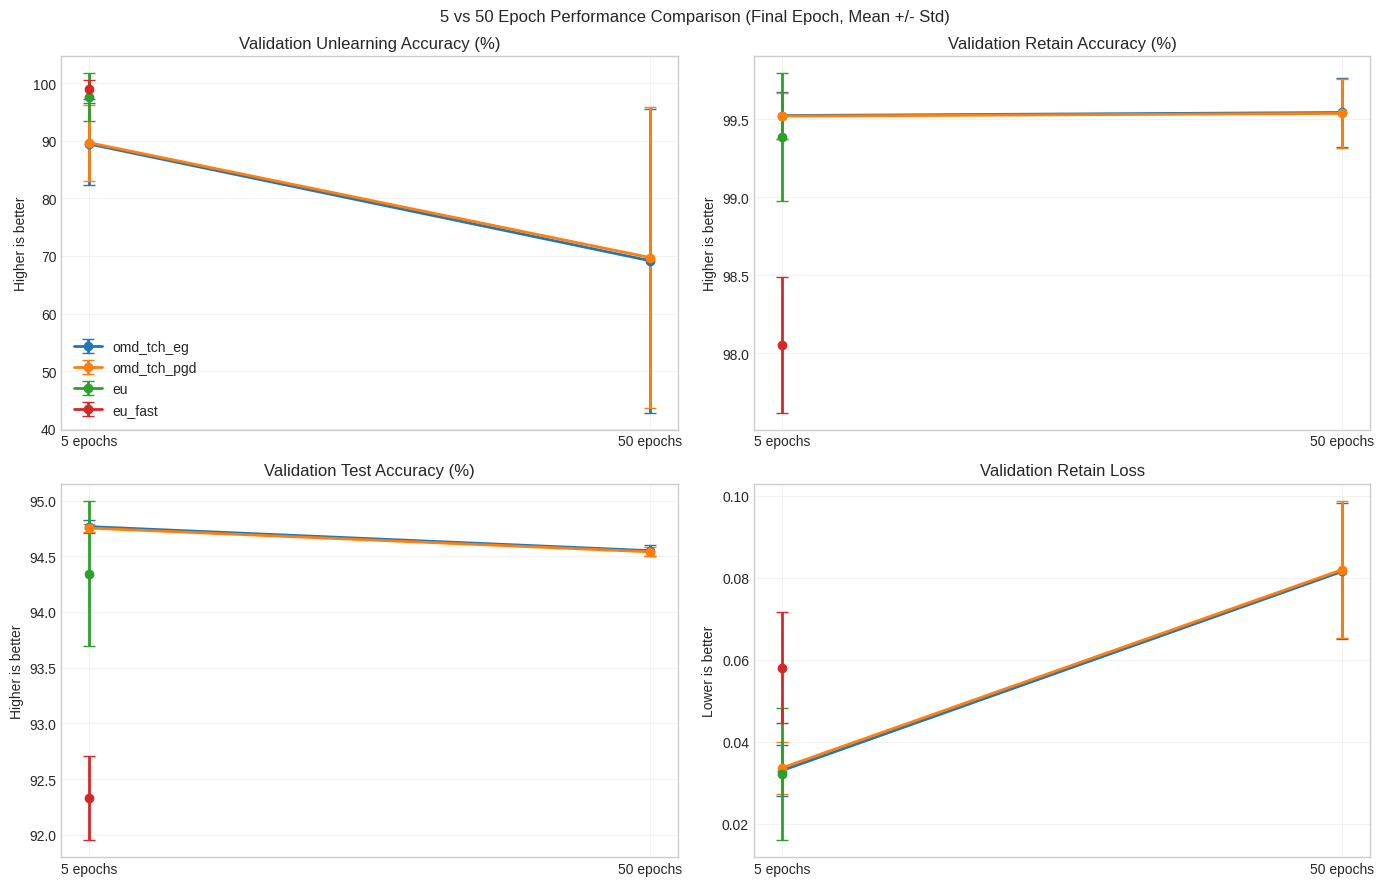

In [10]:
# Compare performance between 5-epoch and 50-epoch runs (final-epoch metrics).
this_dir = Path('.').resolve()

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'output_omd_sweep').exists() and (candidate / 'output').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate project root from {start}')

project_root = find_project_root(this_dir)

base_5 = project_root / 'output' / 'resnet18' / 'cifar10' / 'forget_10.0%' / 'RL'
base_50_primary = project_root / 'output_omd_sweep' / 'resnet18' / 'cifar10' / 'forget_10.0%' / 'RL'
base_50_fallback = base_5

# Add EU and EU-Fast to the comparison set.
methods = ['omd_tch_eg', 'omd_tch_pgd', 'eu', 'eu_fast']

def collect_final_metrics(log_paths, expected_last_epoch):
    rows = []
    for p in sorted(set(log_paths)):
        try:
            with open(p, 'r', encoding='utf-8') as f:
                d = json.load(f)
            epochs = d.get('epochs', [])
            if not epochs:
                continue
            max_epoch = max(e.get('epoch', -1) for e in epochs)
            if max_epoch != expected_last_epoch:
                continue
            final = [e for e in epochs if e.get('epoch') == expected_last_epoch]
            if not final:
                continue
            e = final[0]
            rows.append({
                'run': p.parent.name,
                'retain_loss': e.get('retain_loss'),
                'forget_loss': e.get('forget_loss'),
                'retain_acc': e.get('retain_acc'),
                'ua': e.get('forget_acc'),
                'test_acc': e.get('test_acc'),
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

summary_rows = []

for method in methods:
    # Standard 5-epoch path.
    logs_5 = list((base_5 / method).glob('seed_*_train_*/training_log.json'))

    # 50-epoch logs can appear in sweep folders or in regular output folders.
    logs_50 = []
    logs_50 += list((base_50_primary / method).glob('seed_*_train_*/eta_*_epoch_50/training_log.json'))
    logs_50 += list((base_50_fallback / method).glob('seed_*_train_*/eta_*_epoch_50/training_log.json'))
    logs_50 += list((base_50_fallback / method).glob('seed_*_train_*/training_log.json'))

    df5_final = collect_final_metrics(logs_5, expected_last_epoch=4)
    df50_final = collect_final_metrics(logs_50, expected_last_epoch=49)

    if not df5_final.empty:
        summary_rows.append({
            'method': method,
            'setting': '5 epochs',
            'n_runs': len(df5_final),
            'retain_loss_mean': df5_final['retain_loss'].mean(),
            'retain_loss_std': df5_final['retain_loss'].std(ddof=0),
            'forget_loss_mean': df5_final['forget_loss'].mean(),
            'forget_loss_std': df5_final['forget_loss'].std(ddof=0),
            'retain_acc_mean': df5_final['retain_acc'].mean(),
            'retain_acc_std': df5_final['retain_acc'].std(ddof=0),
            'ua_mean': df5_final['ua'].mean(),
            'ua_std': df5_final['ua'].std(ddof=0),
            'test_acc_mean': df5_final['test_acc'].mean(),
            'test_acc_std': df5_final['test_acc'].std(ddof=0),
        })

    if not df50_final.empty:
        summary_rows.append({
            'method': method,
            'setting': '50 epochs',
            'n_runs': len(df50_final),
            'retain_loss_mean': df50_final['retain_loss'].mean(),
            'retain_loss_std': df50_final['retain_loss'].std(ddof=0),
            'forget_loss_mean': df50_final['forget_loss'].mean(),
            'forget_loss_std': df50_final['forget_loss'].std(ddof=0),
            'retain_acc_mean': df50_final['retain_acc'].mean(),
            'retain_acc_std': df50_final['retain_acc'].std(ddof=0),
            'ua_mean': df50_final['ua'].mean(),
            'ua_std': df50_final['ua'].std(ddof=0),
            'test_acc_mean': df50_final['test_acc'].mean(),
            'test_acc_std': df50_final['test_acc'].std(ddof=0),
        })

comp = pd.DataFrame(summary_rows)
if comp.empty:
    raise ValueError('No valid 5-epoch or 50-epoch runs found for comparison.')

display(comp.sort_values(['method', 'setting']).reset_index(drop=True))

# Plot mean +/- std comparison for key metrics.
metrics = [
    ('ua', 'Validation Unlearning Accuracy (%)', True),
    ('retain_acc', 'Validation Retain Accuracy (%)', True),
    ('test_acc', 'Validation Test Accuracy (%)', True),
    ('retain_loss', 'Validation Retain Loss', False),
]

x_labels = ['5 epochs', '50 epochs']
x_map = {label: i for i, label in enumerate(x_labels)}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (m, title, higher_better) in zip(axes, metrics):
    for method in methods:
        sub = comp[comp['method'] == method]
        if sub.empty:
            continue
        sub = sub.set_index('setting')
        order = [s for s in x_labels if s in sub.index]
        if not order:
            continue

        x = [x_map[s] for s in order]
        y = [sub.loc[s, f'{m}_mean'] for s in order]
        e = [sub.loc[s, f'{m}_std'] for s in order]
        ax.errorbar(x, y, yerr=e, marker='o', linewidth=2, capsize=4, label=method)

    ax.set_title(title)
    ax.set_xticks(np.arange(len(x_labels)), x_labels)
    ax.grid(alpha=0.25)
    ax.set_ylabel('Higher is better' if higher_better else 'Lower is better')

axes[0].legend(frameon=False)
plt.suptitle('5 vs 50 Epoch Performance Comparison (Final Epoch, Mean +/- Std)')
plt.tight_layout()
plt.show()

Prefix eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3: found 20 runs
 - omd_tch_eg/seed_1_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_eg/seed_2_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_eg/seed_3_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_eg/seed_4_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_eg/seed_5_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_pgd/seed_1_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_pgd/seed_2_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_pgd/seed_3_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_pgd/seed_4_train_1/eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3_epoch_5_flt_ga/training_log.json
 - omd_tch_pgd/seed_5_train_1/eta_0p1_rw_1p0_fw_1p0_fref

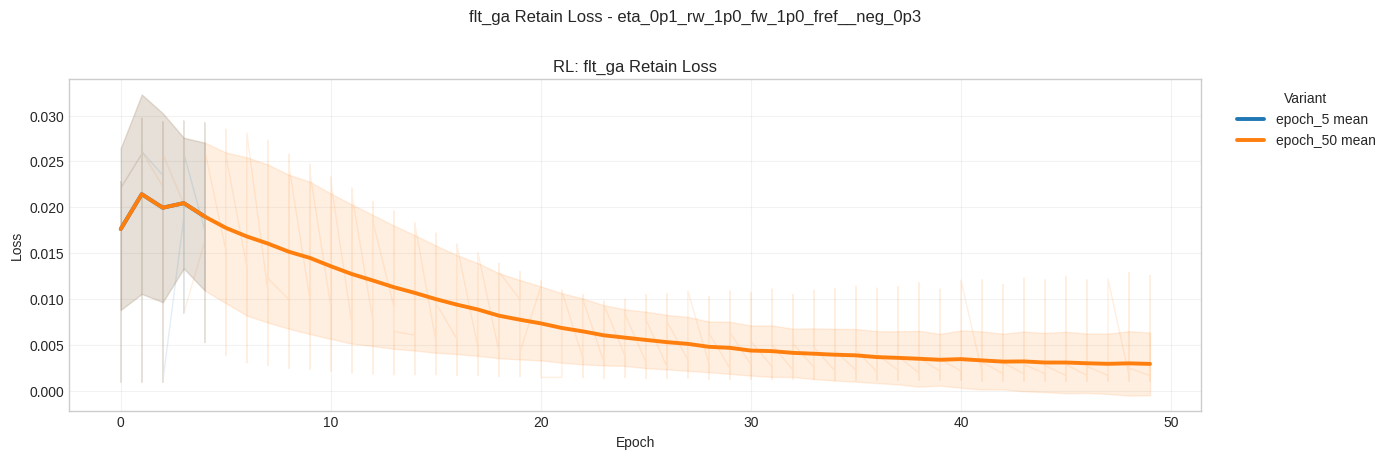

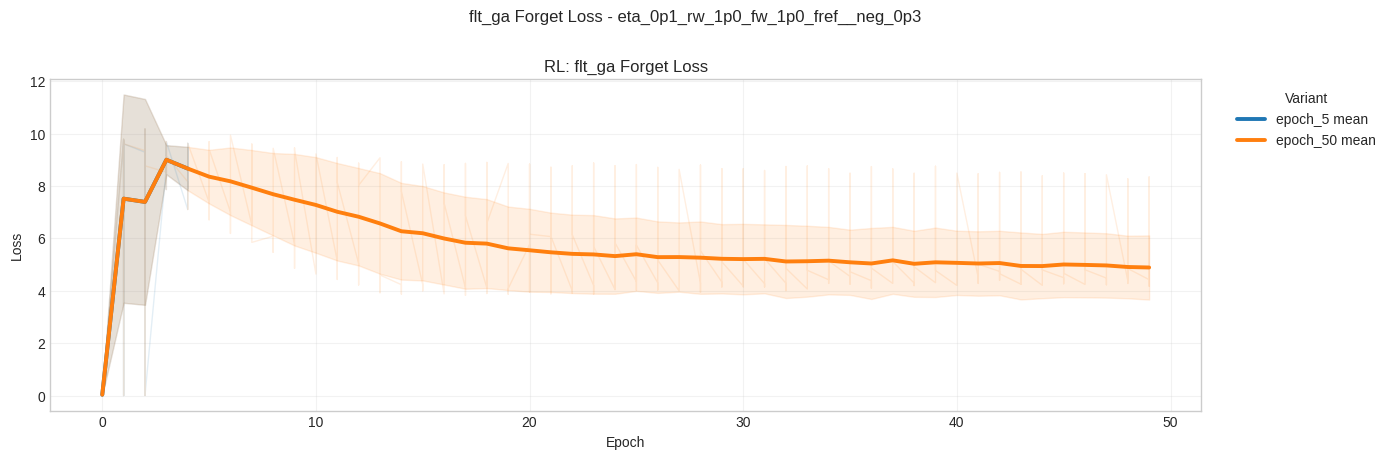

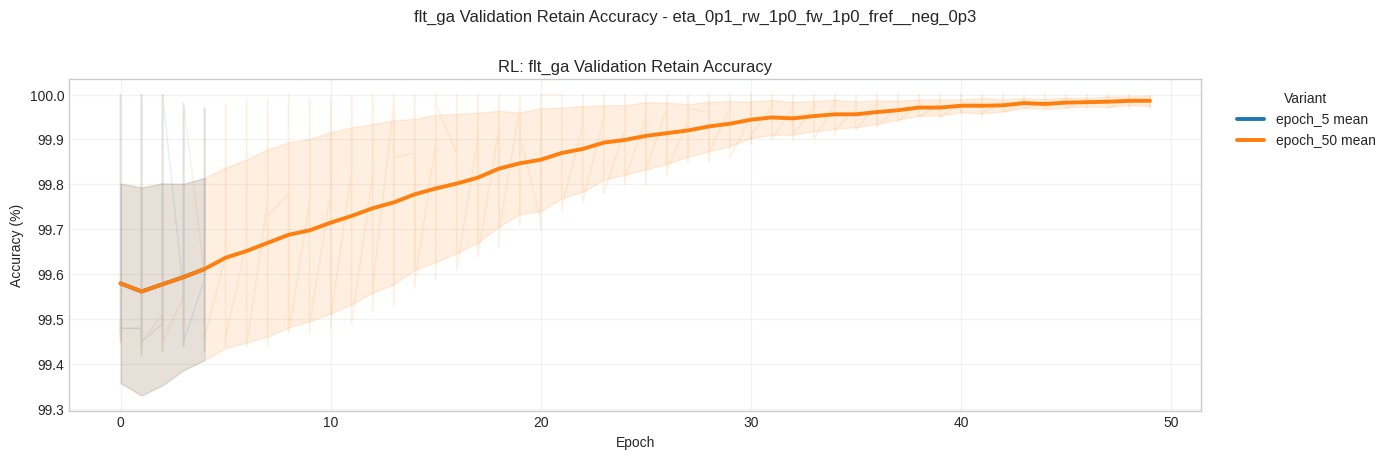

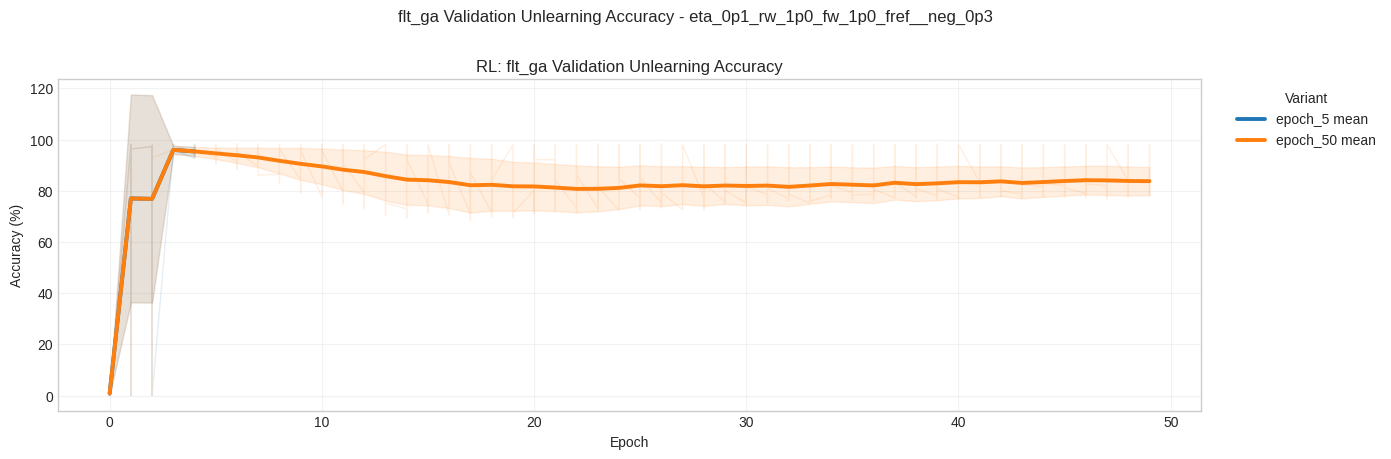

In [11]:
# Compare exact `flt_ga` hyperparameter pairs without mixing different settings.
# This plots four metrics for one prefix at a time, with two solid mean lines:
# one for the `epoch_5` variant and one for the `epoch_50` variant.
this_dir = Path('.').resolve()

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'output_omd_sweep').exists() and (candidate / 'output').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate project root from {start}')

project_root = find_project_root(this_dir)
sweep_root = project_root / 'output_omd_sweep' / 'resnet18' / 'cifar10' / 'forget_10.0%' / 'RL'

# Change or extend this list if you want to compare more matched prefix pairs.
comparison_prefixes = [
    'eta_0p1_rw_1p0_fw_1p0_fref__neg_0p3',
]


def load_pair(prefix: str) -> pd.DataFrame:
    log_files = (
        sorted(sweep_root.glob(f'**/{prefix}_epoch_5_flt_ga/training_log.json'))
        + sorted(sweep_root.glob(f'**/{prefix}_epoch_50_flt_ga/training_log.json'))
    )

    print(f'Prefix {prefix}: found {len(log_files)} runs')
    for log_path in log_files:
        print(' -', log_path.relative_to(sweep_root))

    records = []
    for log_path in log_files:
        with open(log_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        epochs = data.get('epochs', [])
        if not epochs:
            continue

        run_config = log_path.parent.name
        method = log_path.parents[3].name
        variant = 'epoch_50' if '_epoch_50_' in run_config else 'epoch_5'

        for ep in epochs:
            records.append({
                'method': method,
                'run_config': run_config,
                'variant': variant,
                'epoch': ep.get('epoch'),
                'retain_loss': ep.get('retain_loss'),
                'forget_loss': ep.get('forget_loss'),
                'retain_acc': ep.get('retain_acc'),
                'forget_acc': ep.get('forget_acc'),
            })

    frame = pd.DataFrame(records)
    if frame.empty:
        raise ValueError(f'No flt_ga epoch records found for prefix {prefix}')

    return frame.sort_values(['method', 'variant', 'run_config', 'epoch']).reset_index(drop=True)


def plot_metric_grid(frame: pd.DataFrame, prefix: str, metric_col: str, title: str, ylabel: str):
    methods = sorted(frame['method'].unique())
    fig, axes = plt.subplots(len(methods), 1, figsize=(14, 4.5 * len(methods)), sharex=True)
    if len(methods) == 1:
        axes = np.array([axes])

    for i, method in enumerate(methods):
        ax = axes[i]
        sub = frame[frame['method'] == method]

        for variant, color in [('epoch_5', 'tab:blue'), ('epoch_50', 'tab:orange')]:
            cfg = sub[sub['variant'] == variant]
            if cfg.empty:
                continue

            # Light individual-run traces, grouped only within the exact same variant.
            for run_config, g in cfg.groupby('run_config'):
                g = g.sort_values('epoch')
                ax.plot(g['epoch'], g[metric_col], color=color, alpha=0.12, linewidth=1.0)

            mean_by_epoch = cfg.groupby('epoch')[metric_col].agg(['mean', 'std']).reset_index()
            x = mean_by_epoch['epoch'].to_numpy()
            mean = mean_by_epoch['mean'].to_numpy()
            std = mean_by_epoch['std'].fillna(0).to_numpy()
            ax.plot(x, mean, color=color, linewidth=2.8, label=f'{variant} mean')
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)

        ax.set_title(f'{method}: {title}')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        ax.legend(title='Variant', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')

    axes[-1].set_xlabel('Epoch')
    plt.suptitle(f'{title} - {prefix}', y=1.01)
    plt.tight_layout()
    plt.show()


for prefix in comparison_prefixes:
    frame = load_pair(prefix)
    print('Run configurations:')
    for config in sorted(frame['run_config'].unique()):
        print(' -', config)

    plot_metric_grid(frame, prefix, 'retain_loss', 'flt_ga Retain Loss', 'Loss')
    plot_metric_grid(frame, prefix, 'forget_loss', 'flt_ga Forget Loss', 'Loss')
    plot_metric_grid(frame, prefix, 'retain_acc', 'flt_ga Validation Retain Accuracy', 'Accuracy (%)')
    plot_metric_grid(frame, prefix, 'forget_acc', 'flt_ga Validation Unlearning Accuracy', 'Accuracy (%)')

Loaded 25 runs across 5 hyperparameter configs


,config,RA_mean,RA_std,UA_mean,UA_std,n
0,eta_0p1_rw_1p0_fw_1p0_epoch_50,99.543704,0.246972,69.192,29.514811,5
1,eta_0p1_rw_1p0_fw_1p0_rho_0p0_epoch_50,99.543704,0.246972,69.192,29.514811,5
2,eta_0p1_rw_1p0_fw_1p0_rho_1e_neg_2_epoch_50,99.609383,0.215773,73.662,25.235051,5
3,eta_0p1_rw_1p0_fw_1p0_rho_1e_neg_3_epoch_50,99.552099,0.242250,69.992,28.475524,5
4,eta_0p1_rw_1p0_fw_1p0_rho_1e_neg_4_epoch_50,99.543210,0.247271,68.978,29.595557,5


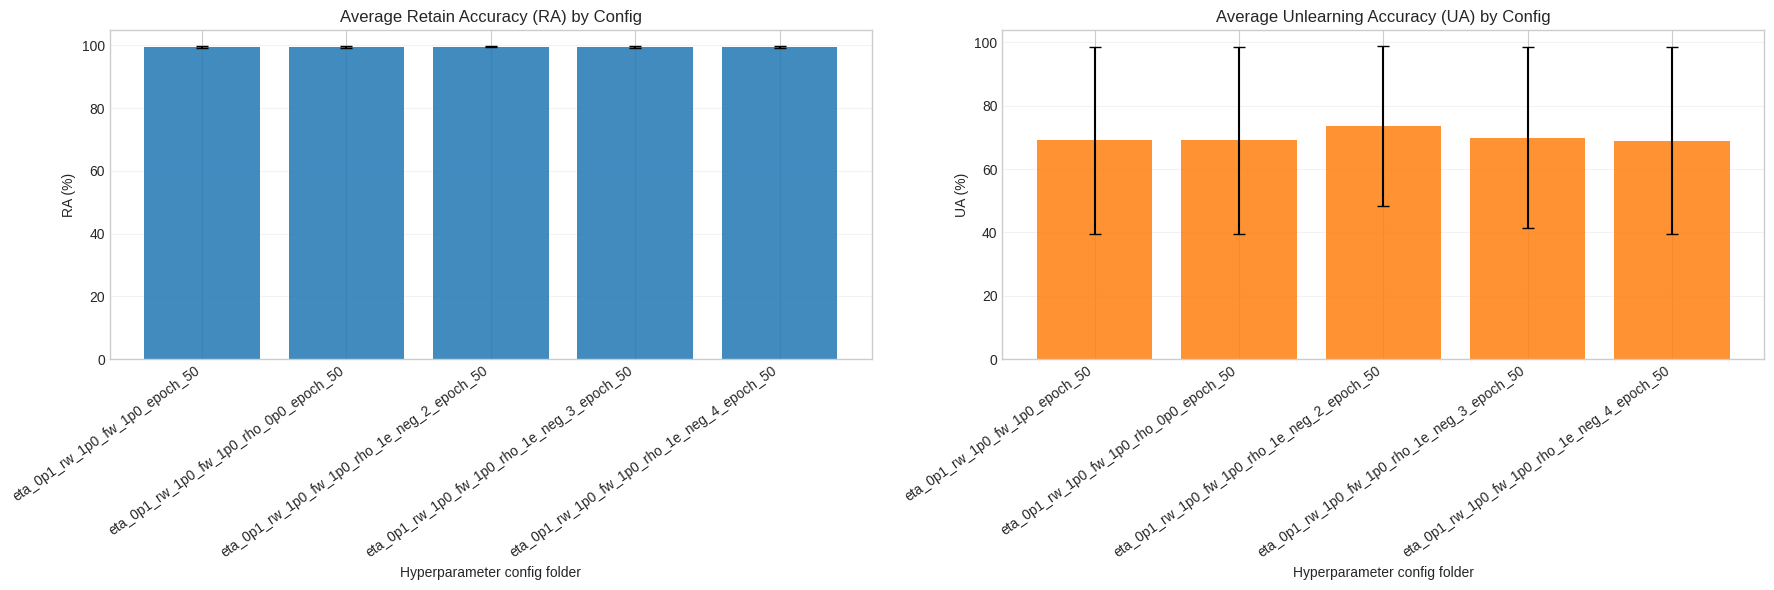

In [12]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/home/yuen_chen/EUPMU-Efficient-Utility-Preserving-Machine-Unlearning/classification/classification_EU_RL/output_classwise")

rows = []
for tlog_path in root.glob("resnet18/cifar10/forget_10.0%/RL/omd_tch_eg/seed_*_train_*/eta_*/training_log.json"):
    run_dir = tlog_path.parent
    config_name = run_dir.name
    seed_tag = run_dir.parent.name

    try:
        seed_id = int(seed_tag.split("_")[1])
    except Exception:
        seed_id = None

    data = json.loads(tlog_path.read_text())
    epochs = data.get("epochs", [])

    ra = None
    ua = None
    if epochs:
        last = epochs[-1]
        ra = last.get("retain_acc")
        ua = last.get("forget_acc")

    # Fallback: derive from evaluation_result if epoch metrics missing.
    if ra is None or ua is None:
        eval_path = run_dir / "evaluation_result.json"
        if eval_path.exists():
            ev = json.loads(eval_path.read_text())
            acc = ev.get("accuracy", {}) if isinstance(ev.get("accuracy"), dict) else {}
            if ra is None and isinstance(acc.get("retain"), (int, float)):
                ra = float(acc["retain"])
            if ua is None and isinstance(acc.get("forget"), (int, float)):
                ua = 100.0 - float(acc["forget"])

    if isinstance(ra, (int, float)) and isinstance(ua, (int, float)):
        rows.append({
            "config": config_name,
            "seed": seed_id,
            "RA": float(ra),
            "UA": float(ua),
            "run_dir": str(run_dir),
        })

if not rows:
    raise RuntimeError(f"No valid runs found under {root}")

df = pd.DataFrame(rows)
summary = (
    df.groupby("config", as_index=False)
      .agg(
          RA_mean=("RA", "mean"),
          RA_std=("RA", "std"),
          UA_mean=("UA", "mean"),
          UA_std=("UA", "std"),
          n=("seed", "count"),
      )
)
summary[["RA_std", "UA_std"]] = summary[["RA_std", "UA_std"]].fillna(0.0)
summary = summary.sort_values("config").reset_index(drop=True)

print(f"Loaded {len(df)} runs across {len(summary)} hyperparameter configs")
display(summary)

x = range(len(summary))
labels = summary["config"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

axes[0].bar(x, summary["RA_mean"], yerr=summary["RA_std"], capsize=4, color="#1f77b4", alpha=0.85)
axes[0].set_title("Average Retain Accuracy (RA) by Config")
axes[0].set_ylabel("RA (%)")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=35, ha="right")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x, summary["UA_mean"], yerr=summary["UA_std"], capsize=4, color="#ff7f0e", alpha=0.85)
axes[1].set_title("Average Unlearning Accuracy (UA) by Config")
axes[1].set_ylabel("UA (%)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=35, ha="right")
axes[1].grid(axis="y", alpha=0.25)

for ax in axes:
    ax.set_xlabel("Hyperparameter config folder")

plt.tight_layout()
plt.show()

In [13]:
# Accuracy progression across output_classwise hyperparameter configs
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

classwise_root = Path(
    "/home/yuen_chen/EUPMU-Efficient-Utility-Preserving-Machine-Unlearning/"
    "classification/classification_EU_RL/output_classwise_ga/resnet18/cifar10/forget_10.0%/RL/omd_tch_eg"
)

# Optional: keep only selected config names; set to None to include all.
selected_configs = None

records = []
for log_path in sorted(classwise_root.glob("seed_*_train_*/eta_*/training_log.json")):
    run_dir = log_path.parent
    config = run_dir.name
    if selected_configs is not None and config not in selected_configs:
        continue

    seed_tag = run_dir.parent.name
    try:
        seed = int(seed_tag.split("_")[1])
    except Exception:
        seed = None

    with open(log_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for ep in data.get("epochs", []):
        epoch = ep.get("epoch")
        ra = ep.get("retain_acc")
        ua = ep.get("forget_acc")
        if isinstance(epoch, (int, float)) and isinstance(ra, (int, float)) and isinstance(ua, (int, float)):
            records.append(
                {
                    "config": config,
                    "seed": seed,
                    "epoch": int(epoch),
                    "retain_acc": float(ra),
                    "forget_acc": float(ua),
                }
            )

frame = pd.DataFrame(records)
if frame.empty:
    raise ValueError(f"No epoch-level accuracy records found under {classwise_root}")

print(f"Loaded {len(frame)} epoch rows from {frame['config'].nunique()} configs and {frame['seed'].nunique()} seeds")
print("Configs:")
for cfg in sorted(frame["config"].unique()):
    print(" -", cfg)


def plot_acc_progression(metric_col: str, title: str, ylabel: str):
    configs = sorted(frame["config"].unique())
    cmap = plt.get_cmap("tab10")

    plt.figure(figsize=(14, 6))

    for i, cfg in enumerate(configs):
        color = cmap(i % 10)
        sub = frame[frame["config"] == cfg]

        # light per-seed traces
        for seed, g in sub.groupby("seed"):
            g = g.sort_values("epoch")
            plt.plot(g["epoch"], g[metric_col], color=color, alpha=0.12, linewidth=1.0)

        # solid mean line across seeds
        mean_by_epoch = sub.groupby("epoch")[metric_col].agg(["mean", "std"]).reset_index()
        x = mean_by_epoch["epoch"].to_numpy()
        mean = mean_by_epoch["mean"].to_numpy()
        std = mean_by_epoch["std"].fillna(0).to_numpy()

        plt.plot(x, mean, color=color, linewidth=2.8, label=f"{cfg} mean")
        plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.10)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", title="Config")
    plt.tight_layout()
    plt.show()


plot_acc_progression("retain_acc", "Validation Retain Accuracy Progression by Config", "RA (%)")
plot_acc_progression("forget_acc", "Validation Unlearning Accuracy Progression by Config", "UA (%)")

ValueError: No epoch-level accuracy records found under /home/yuen_chen/EUPMU-Efficient-Utility-Preserving-Machine-Unlearning/classification/classification_EU_RL/output_classwise_ga/resnet18/cifar10/forget_10.0%/RL/omd_tch_eg

In [ ]:
# OMD-TCH diagnostics: final-vs-best UA, averaged-state UA, and collapse diagnostics
from IPython.display import display

summary_rows = []
for log_path in sorted(classwise_root.glob("seed_*_train_*/eta_*/training_log.json")):
    run_dir = log_path.parent
    config = run_dir.name
    if selected_configs is not None and config not in selected_configs:
        continue

    seed_tag = run_dir.parent.name
    try:
        seed = int(seed_tag.split("_")[1])
    except Exception:
        seed = None

    with open(log_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    epochs = [
        ep for ep in data.get("epochs", [])
        if isinstance(ep.get("forget_acc"), (int, float))
    ]
    if not epochs:
        continue

    last = epochs[-1]
    best = max(epochs, key=lambda ep: float(ep.get("forget_acc", float("-inf"))))

    eval_path = run_dir / "evaluation_result.json"
    eval_data = {}
    if eval_path.exists():
        with open(eval_path, "r", encoding="utf-8") as f:
            eval_data = json.load(f)

    final_acc = eval_data.get("accuracy", {}) if isinstance(eval_data.get("accuracy", {}), dict) else {}
    avg_acc = eval_data.get("avg_accuracy", {}) if isinstance(eval_data.get("avg_accuracy", {}), dict) else {}

    summary_rows.append(
        {
            "config": config,
            "seed": seed,
            "final_epoch": int(last.get("epoch", -1)),
            "best_epoch": int(best.get("epoch", -1)),
            "final_ua": float(last.get("forget_acc")),
            "best_ua": float(best.get("forget_acc")),
            "ua_collapse": float(best.get("forget_acc")) - float(last.get("forget_acc")),
            "final_ra": float(last.get("retain_acc")) if isinstance(last.get("retain_acc"), (int, float)) else np.nan,
            "final_param_update_norm": float(last.get("param_update_norm")) if isinstance(last.get("param_update_norm"), (int, float)) else np.nan,
            "final_overlap": float(last.get("rl_label_overlap")) if isinstance(last.get("rl_label_overlap"), (int, float)) else np.nan,
            "final_overlap_ratio": float(last.get("rl_label_overlap_ratio")) if isinstance(last.get("rl_label_overlap_ratio"), (int, float)) else np.nan,
            "eval_final_ua": float(final_acc.get("forget")) if isinstance(final_acc.get("forget"), (int, float)) else np.nan,
            "avg_state_ua": float(avg_acc.get("forget")) if isinstance(avg_acc.get("forget"), (int, float)) else np.nan,
        }
    )

summary = pd.DataFrame(summary_rows)
if summary.empty:
    raise ValueError("No OMD-TCH summary rows found for diagnostics")

summary = summary.sort_values(["config", "seed"]).reset_index(drop=True)
display(summary[[
    "config", "seed", "best_epoch", "final_epoch", "best_ua", "final_ua",
    "ua_collapse", "avg_state_ua", "final_param_update_norm", "final_overlap_ratio"
]])

cfg_summary = (
    summary.groupby("config")[["best_ua", "final_ua", "ua_collapse", "avg_state_ua"]]
    .agg(["mean", "std"]) 
    .round(2)
)
display(cfg_summary)

configs = sorted(summary["config"].unique())
cmap = plt.get_cmap("tab10")
color_map = {cfg: cmap(i % 10) for i, cfg in enumerate(configs)}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Final vs best UA: last-iterate instability shows up below the y=x line.
ax = axes[0, 0]
for cfg in configs:
    sub = summary[summary["config"] == cfg]
    ax.scatter(sub["best_ua"], sub["final_ua"], s=70, color=color_map[cfg], alpha=0.9, label=cfg)
lims = [summary[["best_ua", "final_ua"]].min().min() - 2, summary[["best_ua", "final_ua"]].max().max() + 2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1.2)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Best UA over epochs (%)")
ax.set_ylabel("Final UA (%)")
ax.set_title("Last Iterate vs Best Iterate")
ax.grid(alpha=0.25)

# Final UA vs averaged-state UA: OMD online-to-batch averaging should reduce collapse if it helps.
ax = axes[0, 1]
for cfg in configs:
    sub = summary[summary["config"] == cfg].dropna(subset=["avg_state_ua"])
    ax.scatter(sub["avg_state_ua"], sub["final_ua"], s=70, color=color_map[cfg], alpha=0.9)
lims = [summary[["avg_state_ua", "final_ua"]].min().min() - 2, summary[["avg_state_ua", "final_ua"]].max().max() + 2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1.2)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Averaged-state UA from evaluation_result.json (%)")
ax.set_ylabel("Final UA (%)")
ax.set_title("Averaged State vs Last Iterate")
ax.grid(alpha=0.25)

# Collapse vs final parameter update norm: large late updates may coincide with collapse.
ax = axes[1, 0]
for cfg in configs:
    sub = summary[summary["config"] == cfg]
    ax.scatter(sub["final_param_update_norm"], sub["ua_collapse"], s=70, color=color_map[cfg], alpha=0.9)
ax.set_xlabel("Final-epoch parameter update norm")
ax.set_ylabel("Best UA - Final UA (%)")
ax.set_title("Collapse vs Update Magnitude")
ax.grid(alpha=0.25)

# Collapse vs RL label overlap ratio: checks whether bad runs align with label-noise drift.
ax = axes[1, 1]
for cfg in configs:
    sub = summary[summary["config"] == cfg]
    ax.scatter(sub["final_overlap_ratio"], sub["ua_collapse"], s=70, color=color_map[cfg], alpha=0.9)
ax.axvline(1.0, linestyle="--", color="black", linewidth=1.2)
ax.set_xlabel("Final RL label overlap ratio (actual / expected)")
ax.set_ylabel("Best UA - Final UA (%)")
ax.set_title("Collapse vs RL Label Overlap")
ax.grid(alpha=0.25)

handles = [plt.Line2D([0], [0], marker='o', color='w', label=cfg, markerfacecolor=color_map[cfg], markersize=8) for cfg in configs]
fig.legend(handles=handles, labels=configs, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", title="Config")
fig.tight_layout()
plt.show()

print("Runs with the largest last-iterate collapse:")
display(summary.sort_values("ua_collapse", ascending=False).head(10))


ValueError: No OMD-TCH summary rows found for diagnostics

# Combined Comparison: All Algorithms and Hyperparameters

This section creates unified plots showing all methods (EU, EU_Fast, OMD) and their hyperparameter variations on the same plot for direct comparison.

In [66]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# GA results (OMD-TCH, EUPMU-GA)
root = Path("output_classwise_ga/resnet18/cifar10/forget_10.0%/RL")

# RL results: linear_scalarization + EUPMU RL (eu, eu_fast)
ls_root = Path("output_classwise/resnet18/cifar10/forget_10.0%/RL")


def parse_token_block(setting: str, key: str, stop_keys: set[str]) -> str:
    tokens = setting.split("_")
    if key not in tokens:
        return ""
    start = tokens.index(key) + 1
    out = []
    for tok in tokens[start:]:
        if tok in stop_keys:
            break
        out.append(tok)
    return "_".join(out)


def decode_tag(tag: str) -> str:
    if not tag:
        return ""
    return tag.replace("_neg_", "-").replace("p", ".")


def load_eval_records(search_root: Path, fallback_method: str = "unknown", source: str = "") -> list[dict]:
    src_label = source or search_root.parts[-4]  # e.g. "output_classwise_ga"
    out = []
    for eval_path in sorted(search_root.glob("**/evaluation_result.json")):
        try:
            rel = eval_path.relative_to(search_root)
            parts = rel.parts

            class_idx = next((i for i, p in enumerate(parts) if p.startswith("class_")), None)
            if class_idx is None:
                continue

            method = parts[class_idx - 1] if class_idx >= 1 else fallback_method
            class_tag = parts[class_idx]
            run_tag = parts[class_idx + 1] if class_idx + 1 < len(parts) else ""
            setting = parts[class_idx + 2] if class_idx + 2 < len(parts) else ""

            if not run_tag.startswith("seed_"):
                continue

            class_id = int(class_tag.split("_", 1)[1])

            with open(eval_path, "r", encoding="utf-8") as f:
                obj = json.load(f)

            acc = obj.get("accuracy", {})
            retain = acc.get("retain")
            forget = acc.get("forget")
            test = acc.get("test")

            if not all(isinstance(v, (int, float)) for v in (retain, forget, test)):
                continue

            lr_tag  = parse_token_block(setting, "ulr", {"eta", "wlr", "err", "epoch", "rw", "fw", "rho", "flt"})
            rho_tag = parse_token_block(setting, "rho", {"epoch"})
            flt_tag = parse_token_block(setting, "flt", set())
            lr_label  = f"lr={decode_tag(lr_tag)}"  if lr_tag  else ""
            rho_label = f"rho={decode_tag(rho_tag)}" if rho_tag else ""

            method_full = method
            if method.startswith("omd_tch"):
                suffix = "_".join([x for x in (lr_label, rho_label) if x])
                if suffix:
                    method_full = f"{method}_{suffix}"
            elif method == "linear_scalarization" and flt_tag:
                method_full = f"linear_scalarization_{flt_tag}"

            out.append({
                "method":      method,
                "method_full": method_full,
                "class_id":    class_id,
                "run_tag":     run_tag,
                "setting":     setting,
                "lr_tag":      lr_tag,
                "rho_tag":     rho_tag,
                "flt_tag":     flt_tag,
                "source":      src_label,
                "retain":  float(retain),
                "forget":  float(forget),
                "test":    float(test),
            })
        except Exception:
            continue
    return out


records = load_eval_records(root, source="output_classwise_ga")

if ls_root.exists():
    ls_records = load_eval_records(ls_root, fallback_method="linear_scalarization", source="output_classwise")
    print(f"Loaded {len(ls_records)} records from {ls_root}")
    records.extend(ls_records)
else:
    print(f"[warn] RL root not found: {ls_root}")

raw_df = pd.DataFrame(records)
if raw_df.empty:
    raise ValueError(f"No valid evaluation_result.json rows found under {root}")

# If a non-OMD method has multiple settings, split by full setting for fair comparison.
for method in sorted(raw_df["method"].unique()):
    method_mask = raw_df["method"] == method
    n_settings = raw_df.loc[method_mask, "setting"].nunique()
    if n_settings > 1 and not method.startswith("omd_tch") and method != "linear_scalarization":
        raw_df.loc[method_mask, "method_full"] = (
            raw_df.loc[method_mask, "method"] + "_" + raw_df.loc[method_mask, "setting"]
        )

df_unified = (
    raw_df.groupby(["method_full", "class_id"], as_index=False)
    .agg(
        test_mean=("test", "mean"),
        forget_mean=("forget", "mean"),
        retain_mean=("retain", "mean"),
        num_rows=("run_tag", "size"),
        num_seeds=("run_tag", "nunique"),
    )
    .sort_values(["method_full", "class_id"])
    .reset_index(drop=True)
)

output_dir = root / "analysis" / "combined_comparison_20260414"
output_dir.mkdir(parents=True, exist_ok=True)

metrics      = ["test_mean", "forget_mean", "retain_mean"]
metric_names = ["Test Accuracy", "Forget Accuracy", "Retain Accuracy"]

methods_unique = df_unified["method_full"].unique()
colors  = {}
markers = {}
color_palette  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
marker_palette = ["o", "s", "^", "v", "D", "X", "P", "*", "<", ">"]

for i, method in enumerate(sorted(methods_unique)):
    colors[method]  = color_palette[i % len(color_palette)]
    markers[method] = marker_palette[i % len(marker_palette)]

print(f"Loaded {len(raw_df)} evaluation files from {root}")
print(f"Methods to plot: {sorted(methods_unique)}")
print("Runs per line:")
display(df_unified.groupby("method_full")[["num_rows", "num_seeds"]].max().reset_index())

print("\nUnique rho values per OMD method/lr from discovered files:")
rho_view = (
    raw_df[raw_df["method"].str.startswith("omd_tch")]
    .groupby(["method", "lr_tag"])["rho_tag"]
    .nunique()
    .reset_index(name="num_rho_values")
)
rho_view

Loaded 1000 records from output_classwise/resnet18/cifar10/forget_10.0%/RL
Loaded 1921 evaluation files from output_classwise_ga/resnet18/cifar10/forget_10.0%/RL
Methods to plot: ['eu_fast_ulr_2e_neg_3_wlr_1_err_0p01_epoch_5', 'eu_fast_ulr_2e_neg_3_wlr_1_err_0p01_epoch_5_flt_ga', 'eu_ulr_1e_neg_3_wlr_1_err_0p01_epoch_5', 'eu_ulr_1e_neg_3_wlr_1_err_0p01_epoch_5_flt_ga', 'eu_ulr_1e_neg_3_wlr_1_err_0p01_rref_0p0_fref__neg_10p0_epoch_5_flt_ga', 'linear_scalarization', 'linear_scalarization_ga', 'linear_scalarization_rl', 'omd_tch_eg_lr=1e-2_rho=0.0', 'omd_tch_eg_lr=1e-2_rho=0.1', 'omd_tch_eg_lr=1e-2_rho=1e-2', 'omd_tch_eg_lr=1e-2_rho=1e-4', 'omd_tch_eg_lr=1e-3_rho=0.0', 'omd_tch_eg_lr=1e-3_rho=0.1', 'omd_tch_eg_lr=1e-3_rho=1e-2', 'omd_tch_eg_lr=1e-3_rho=1e-4', 'omd_tch_pgd_lr=1e-2_rho=0.0', 'omd_tch_pgd_lr=1e-2_rho=0.1', 'omd_tch_pgd_lr=1e-2_rho=1e-2', 'omd_tch_pgd_lr=1e-2_rho=1e-4', 'omd_tch_pgd_lr=1e-3_rho=0.0', 'omd_tch_pgd_lr=1e-3_rho=0.1', 'omd_tch_pgd_lr=1e-3_rho=1e-2', 'omd_tch_pgd_

,method_full,num_rows,num_seeds
0,eu_fast_ulr_2e_neg_3_wlr_1_err_0p01_epoch_5,5,5
1,eu_fast_ulr_2e_neg_3_wlr_1_err_0p01_epoch_5_fl...,5,5
2,eu_ulr_1e_neg_3_wlr_1_err_0p01_epoch_5,5,5
3,eu_ulr_1e_neg_3_wlr_1_err_0p01_epoch_5_flt_ga,5,5
4,eu_ulr_1e_neg_3_wlr_1_err_0p01_rref_0p0_fref__...,5,5
5,linear_scalarization,4,4
6,linear_scalarization_ga,10,5
7,linear_scalarization_rl,5,5
8,omd_tch_eg_lr=1e-2_rho=0.0,10,5
9,omd_tch_eg_lr=1e-2_rho=0.1,10,5



Unique rho values per OMD method/lr from discovered files:


,method,lr_tag,num_rho_values
0,omd_tch_eg,1e_neg_2,4
1,omd_tch_eg,1e_neg_3,4
2,omd_tch_pgd,1e_neg_2,4
3,omd_tch_pgd,1e_neg_3,4


Best OMD-TCH variant: omd_tch_eg_lr=1e-2_rho=0.1
Saved: all_methods_vertical.png


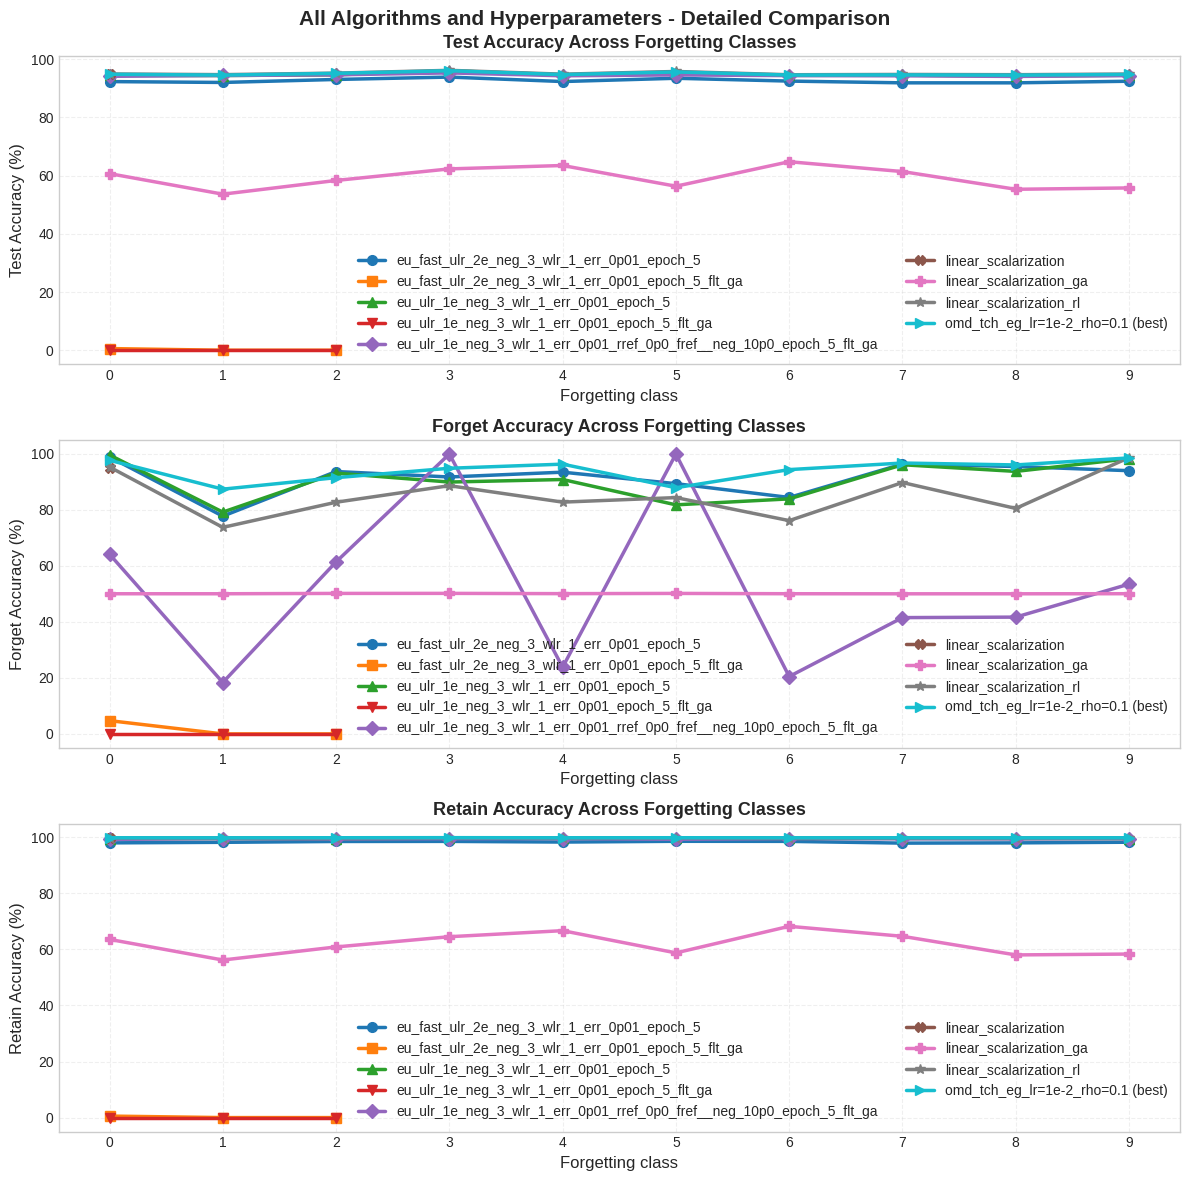

In [67]:
# === Vertical layout plot (cleaner for individual metric viewing) ===

# For OMD-TCH variants, keep only the single best-performing hyperparameter line
# (highest average of test_mean, forget_mean, retain_mean across all classes).
omd_methods = [m for m in methods_unique if "omd_tch" in m]
non_omd_methods = [m for m in methods_unique if "omd_tch" not in m]

best_omd = None
if omd_methods:
    best_omd = max(
        omd_methods,
        key=lambda m: df_unified[df_unified["method_full"] == m][
            ["test_mean", "forget_mean", "retain_mean"]
        ].values.mean(),
    )

plot_methods = sorted(non_omd_methods) + ([best_omd] if best_omd else [])

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle('All Algorithms and Hyperparameters - Detailed Comparison', fontsize=15, fontweight='bold')

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx]

    for method in plot_methods:
        label = f"{method} (best)" if method == best_omd else method
        data = df_unified[df_unified['method_full'] == method].sort_values('class_id')
        ax.plot(data['class_id'], data[metric],
                label=label,
                color=colors[method],
                marker=markers[method],
                linewidth=2.5,
                markersize=7)

    ax.set_xlabel('Forgetting class', fontsize=12)
    ax.set_ylabel(f'{metric_name} (%)', fontsize=12)
    ax.set_title(f'{metric_name} Across Forgetting Classes', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(range(10))

if best_omd:
    print(f"Best OMD-TCH variant: {best_omd}")

plt.tight_layout()
plt.savefig(output_dir / 'all_methods_vertical.png', dpi=150, bbox_inches='tight')
print(f"Saved: all_methods_vertical.png")
plt.show()

In [68]:
# === Generate and display summary table ===

# ── GA methods ────────────────────────────────────────────────────────────
ga_methods = [
    m for m in methods_unique
    if raw_df.loc[raw_df["method_full"] == m, "setting"].str.contains("flt_ga").any()
    or m.endswith("_ga")
]

# ── RL methods ─────────────────────────────────────────────────────────────
# Build a separate seed-averaged frame from output_classwise RL rows only,
# so GA records for the same method_full don't contaminate the averages.
RL_METHODS = {"eu", "eu_fast"}
raw_rl = raw_df[
    (raw_df["source"] == "output_classwise") &
    (~raw_df["setting"].str.contains("flt_ga")) &
    (raw_df["method"].apply(lambda x: x in RL_METHODS or x.startswith("omd_tch")))
].copy()

df_unified_rl = (
    raw_rl.groupby(["method_full", "class_id"], as_index=False)
    .agg(
        test_mean=("test", "mean"),
        forget_mean=("forget", "mean"),
        retain_mean=("retain", "mean"),
        num_rows=("run_tag", "size"),
        num_seeds=("run_tag", "nunique"),
    )
    .sort_values(["method_full", "class_id"])
    .reset_index(drop=True)
)
rl_methods = df_unified_rl["method_full"].unique()

# ── Helpers ────────────────────────────────────────────────────────────────
def build_summary_rows(method_list, source_df):
    rows = []
    for method in method_list:
        subset = source_df[source_df["method_full"] == method]
        test_mean   = subset["test_mean"].mean()
        test_std    = subset["test_mean"].std()
        forget_mean = subset["forget_mean"].mean()
        forget_std  = subset["forget_mean"].std()
        retain_mean = subset["retain_mean"].mean()
        retain_std  = subset["retain_mean"].std()
        avg_mean = np.mean([test_mean, forget_mean, retain_mean])
        rows.append({
            "Method":         method,
            "Test Acc (%)":   f"{test_mean:.2f} ± {test_std:.2f}",
            "Forget Acc (%)": f"{forget_mean:.2f} ± {forget_std:.2f}",
            "Retain Acc (%)": f"{retain_mean:.2f} ± {retain_std:.2f}",
            "Average (%)":    f"{avg_mean:.2f}",
            "_avg_mean": avg_mean,
        })
    return rows

def build_numeric_rows(method_list, source_df, loss_type):
    rows = []
    for method in method_list:
        subset = source_df[source_df["method_full"] == method]
        test_mean   = subset["test_mean"].mean()
        test_std    = subset["test_mean"].std()
        forget_mean = subset["forget_mean"].mean()
        forget_std  = subset["forget_mean"].std()
        retain_mean = subset["retain_mean"].mean()
        retain_std  = subset["retain_mean"].std()
        avg_mean = np.mean([test_mean, forget_mean, retain_mean])
        rows.append({
            "method": method, "loss_type": loss_type,
            "test_mean": test_mean, "test_std": test_std,
            "forget_mean": forget_mean, "forget_std": forget_std,
            "retain_mean": retain_mean, "retain_std": retain_std,
            "average_mean": avg_mean,
        })
    return rows

# ── Print GA table ─────────────────────────────────────────────────────────
print("\n" + "="*80)
print("AGGREGATE STATISTICS (GA loss) — averaged across all 10 classes")
print("="*80)
ga_df = pd.DataFrame(build_summary_rows(ga_methods, df_unified))
ga_df = ga_df.sort_values("_avg_mean", ascending=False).drop(columns=["_avg_mean"]).reset_index(drop=True)
print(ga_df.to_string(index=False))
print("="*80)

# ── Print RL table ─────────────────────────────────────────────────────────
if len(rl_methods):
    print("\n" + "="*80)
    print("AGGREGATE STATISTICS (RL loss) — averaged across all 10 classes")
    print("="*80)
    rl_df = pd.DataFrame(build_summary_rows(rl_methods, df_unified_rl))
    rl_df = rl_df.sort_values("_avg_mean", ascending=False).drop(columns=["_avg_mean"]).reset_index(drop=True)
    print(rl_df.to_string(index=False))
    print("="*80)

# ── Save CSV ───────────────────────────────────────────────────────────────
all_numeric = (
    build_numeric_rows(ga_methods, df_unified, "ga") +
    build_numeric_rows(rl_methods, df_unified_rl, "rl")
)
summary_numeric_df = pd.DataFrame(all_numeric).sort_values(
    ["loss_type", "average_mean"], ascending=[True, False]
).reset_index(drop=True)
summary_numeric_df.to_csv(output_dir / "plot_matched_summary_ga.csv", index=False)
print(f"\nSummary CSV saved to: {output_dir / 'plot_matched_summary_ga.csv'}")


AGGREGATE STATISTICS (GA loss) — averaged across all 10 classes
                                                               Method Test Acc (%) Forget Acc (%) Retain Acc (%) Average (%)
                                           omd_tch_eg_lr=1e-2_rho=0.1 94.94 ± 0.52   94.19 ± 3.94   99.83 ± 0.02       96.32
                                          omd_tch_pgd_lr=1e-2_rho=0.1 94.79 ± 0.56   94.32 ± 4.09   99.76 ± 0.05       96.29
                                         omd_tch_pgd_lr=1e-2_rho=1e-2 94.70 ± 0.55   94.18 ± 4.46   99.70 ± 0.04       96.19
                                          omd_tch_eg_lr=1e-2_rho=1e-2 94.87 ± 0.53   93.93 ± 4.54   99.76 ± 0.03       96.19
                                           omd_tch_eg_lr=1e-2_rho=0.0 94.66 ± 0.44   93.99 ± 4.27   99.71 ± 0.02       96.12
                                          omd_tch_eg_lr=1e-2_rho=1e-4 94.67 ± 0.44   93.90 ± 4.33   99.71 ± 0.02       96.09
                                         omd_tch_pgd_lr=1e-2

# Visualize the class distributions
